##**HR Recruitment Data Analysis & Visualization**

In this project, we will analyze the cleaned HR recruitment dataset
using Python, Pandas, Matplotlib and Seaborn.

The objective is to understand:
- Candidate demographics
- Recruitment status
- Salary expectations
- Candidate experience
- Interview and technical performance
- Application trends
- Relationships between different variables

In [111]:
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn as sns

**STEP 1- LOAD DATASET**

In [112]:
df = pandas.read_csv("IT_Jobs_cleaned.csv")

In [113]:
print(df.head())

  Application_ID Candidate_Name  Gender  Age       City        State  \
0        APP0001    Anya Butala    Male   27  Ahmedabad      Gujarat   
1        APP0002      Hansh Bal  Female   24    Gurgaon      Haryana   
2        APP0003   Ahana  Yadav    Male   30       Pune  Maharashtra   
3        APP0004      Urvi Bora  Female   38    Chennai   Tamil Nadu   
4        APP0005  Alisha Mammen  Female   34  Hyderabad    Telangana   

  Qualification        Specialization                       College_Name  \
0          B.E.      Computer Science  Dayal, Walia and Gandhi Institute   
1        B.Tech  Software Engineering              Cherian PLC Institute   
2        B.Tech          Data Science   Wagle, Barad and Samra Institute   
3          B.E.       Cloud Computing        Banerjee and Sons Institute   
4           BCA  Software Engineering            Sanghvi Group Institute   

   Graduation_Year  ...  Expected_Salary_LPA Current_Salary_LPA  \
0             2024  ...                 12.

**STEP -2 BASIC DATA UNDERSTANDINGS**

In [114]:
df.shape

(500, 26)

In [115]:
print(df.columns)

Index(['Application_ID', 'Candidate_Name', 'Gender', 'Age', 'City', 'State',
       'Qualification', 'Specialization', 'College_Name', 'Graduation_Year',
       'Experience_Years', 'Previous_Company', 'Applied_Role', 'Department',
       'Skills', 'Certification', 'Expected_Salary_LPA', 'Current_Salary_LPA',
       'Notice_Period_Days', 'Application_Date', 'Interview_Score',
       'Technical_Test_Score', 'Communication_Score', 'Status', 'Work_Mode',
       'Preferred_Location'],
      dtype='object')


In [116]:
df.dtypes

,0
Application_ID,object
Candidate_Name,object
Gender,object
Age,int64
City,object
State,object
Qualification,object
Specialization,object
College_Name,object
Graduation_Year,int64


In [117]:
df['Application_Date'] = pandas.to_datetime(df['Application_Date'])

In [118]:
df.dtypes

,0
Application_ID,object
Candidate_Name,object
Gender,object
Age,int64
City,object
State,object
Qualification,object
Specialization,object
College_Name,object
Graduation_Year,int64


In [119]:
df.isnull().sum()

,0
Application_ID,0
Candidate_Name,0
Gender,0
Age,0
City,0
State,0
Qualification,0
Specialization,0
College_Name,0
Graduation_Year,0


In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
df.dtypes

,0
Application_ID,object
Candidate_Name,object
Gender,object
Age,int64
City,object
State,object
Qualification,object
Specialization,object
College_Name,object
Graduation_Year,int64


In [122]:
df.nunique()   # Uniques Values

,0
Application_ID,500
Candidate_Name,499
Gender,2
Age,18
City,15
State,13
Qualification,7
Specialization,8
College_Name,498
Graduation_Year,13


**STEP -3 UIVARIATE ANALYSIS**

Text(0, 0.5, 'Number of Candidates')

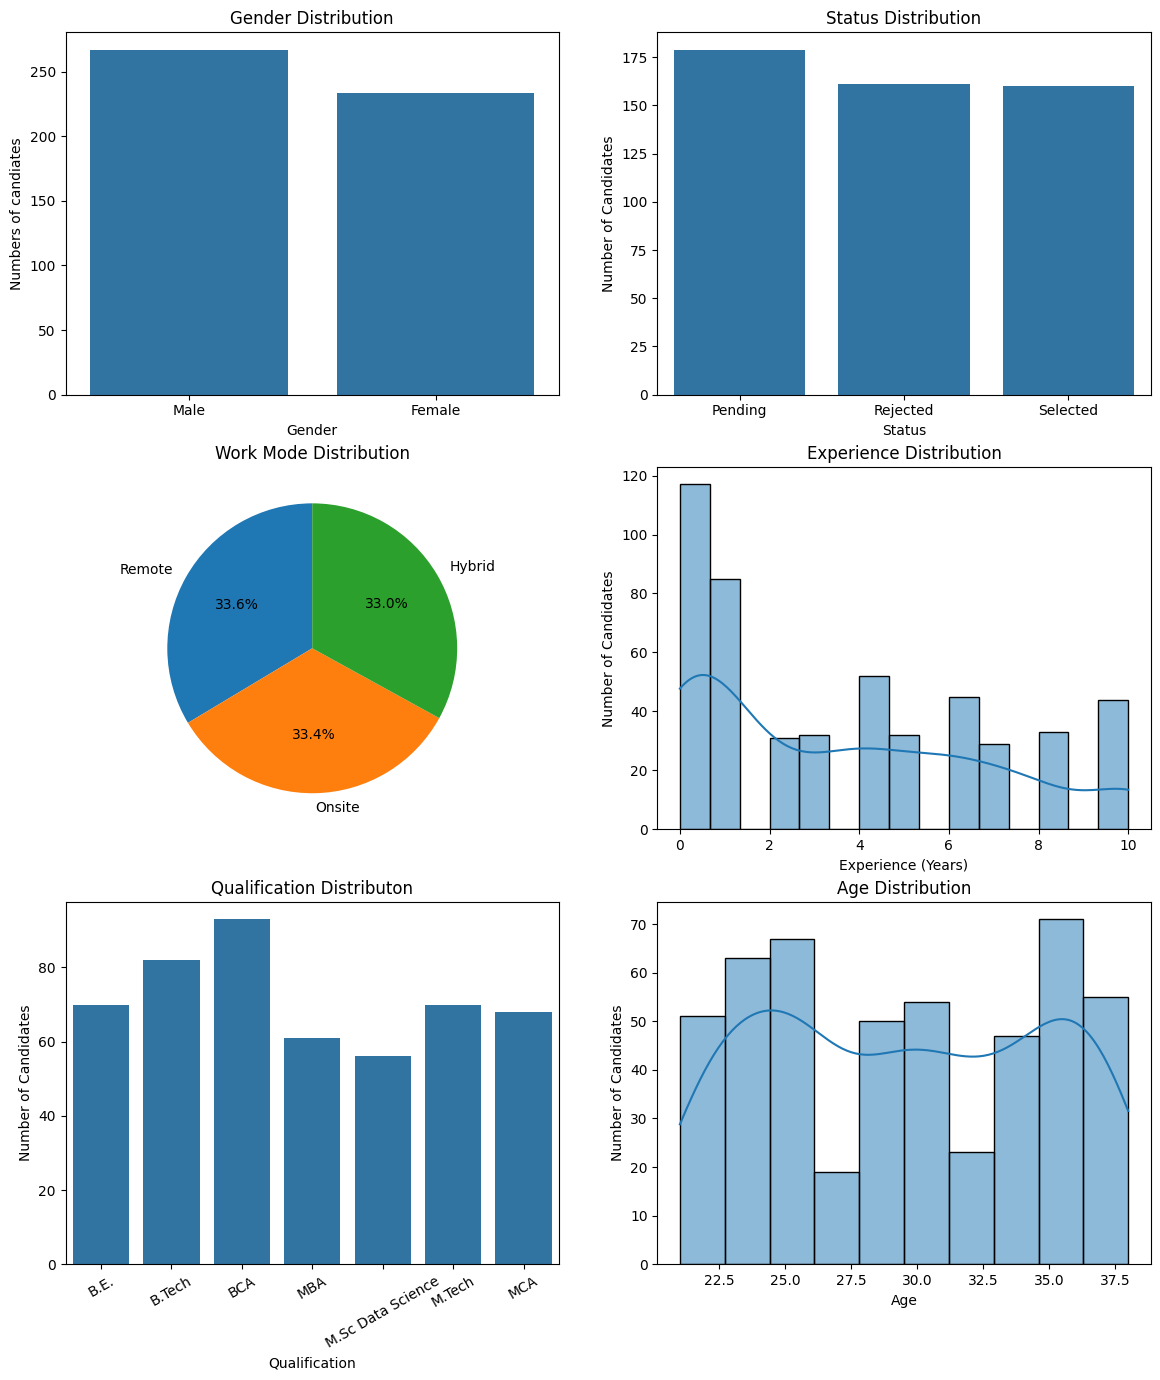

In [123]:
fig, axes = plt.subplots(3,2,figsize=(14,16))

# 1 . Gender
sns.countplot(data=df, x='Gender', ax = axes[0,0])
axes[0,0].set_title("Gender Distribution")
axes[0,0].set_xlabel("Gender")
axes[0,0].set_ylabel("Numbers of candiates")

# 2. Status
sns.countplot(data=df,x='Status', ax= axes[0,1])
axes[0,1].set_title("Status Distribution")
axes[0,1].set_xlabel("Status")
axes[0,1].set_ylabel("Number of Candidates")

# 3. Work Mode
work_mode_counts = df['Work_Mode'].value_counts()

axes[1,0].pie(
    work_mode_counts,
    labels=work_mode_counts.index,
    autopct = '%1.1f%%',
    startangle = 90
)

axes[1,0].set_title('Work Mode Distribution')

# 4. Experience
sns.histplot(data=df, x='Experience_Years', bins=15, kde=True, ax=axes[1,1])
axes[1,1].set_title('Experience Distribution')
axes[1,1].set_xlabel('Experience (Years)')
axes[1,1].set_ylabel('Number of Candidates')

# 5. Qualification Distribution
sns.countplot(data=df, x='Qualification',  ax=axes[2,0])
axes[2,0].set_title('Qualification Distributon')
axes[2,0].set_xlabel('Qualification')
axes[2,0].set_ylabel('Number of Candidates')
axes[2,0].tick_params(axis='x', rotation=30)

# 6. Age Distribution
sns.histplot(data=df, x='Age', bins=10, kde=True, ax=axes[2,1])
axes[2,1].set_title('Age Distribution')
axes[2,1].set_xlabel('Age')
axes[2,1].set_ylabel('Number of Candidates')

**STEP 4 - BIVARIATE ANALYSIS**

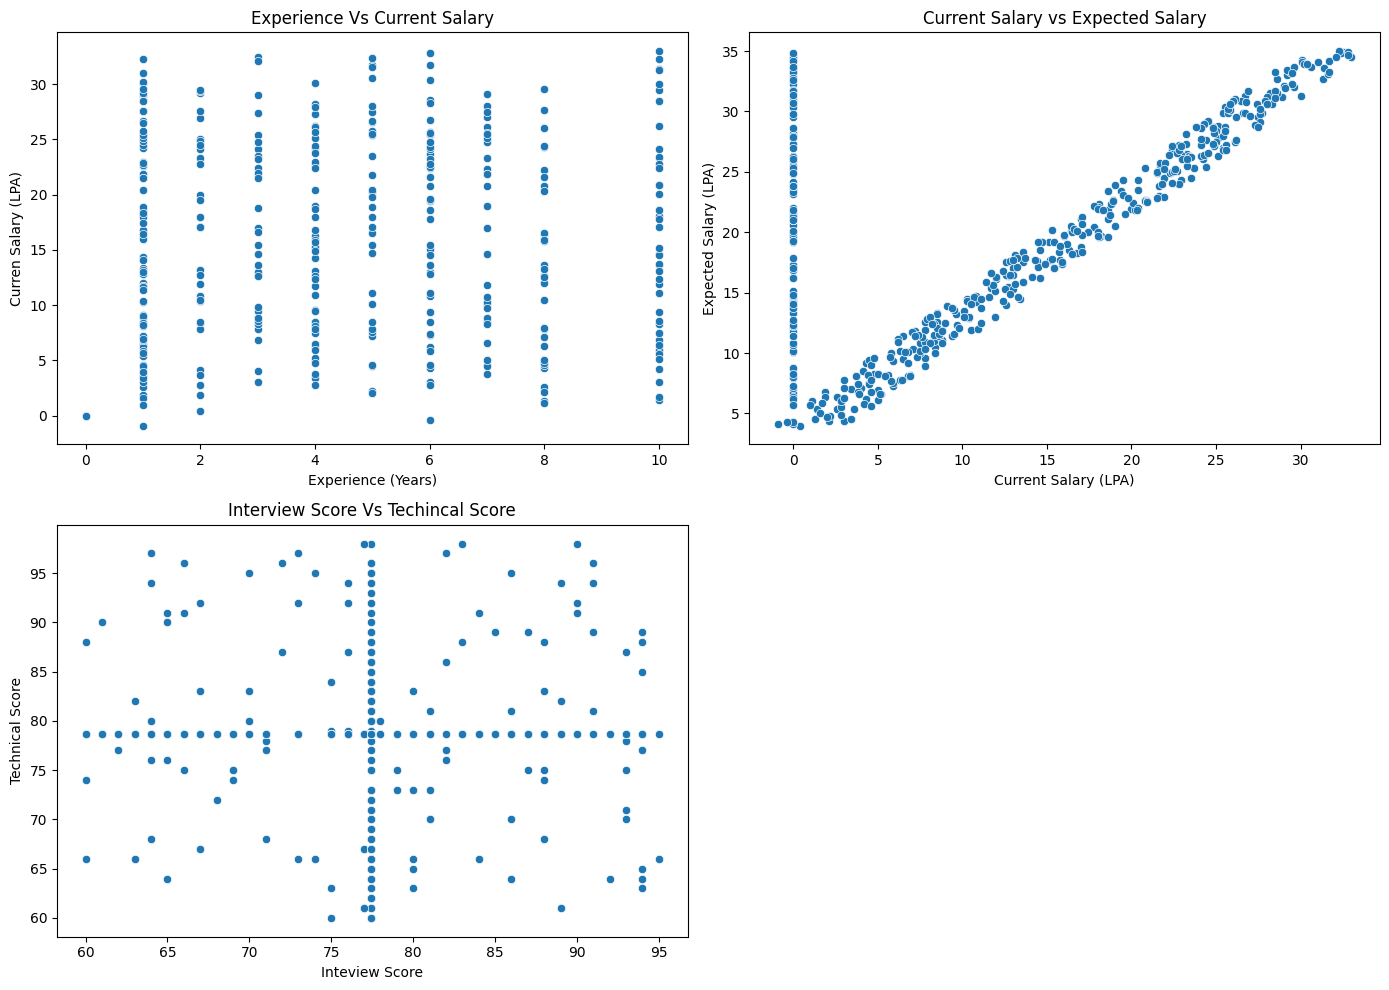

In [132]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

# 1. Experience Vs Current Salary
sns.scatterplot(
    data=df,
    x='Experience_Years',
    y='Current_Salary_LPA',
    ax=axes[0,0]
)

axes[0,0].set_title('Experience Vs Current Salary')
axes[0,0].set_xlabel('Experience (Years)')
axes[0,0].set_ylabel('Curren Salary (LPA)')


# 2. Current Salary vs Expected Salary
sns.scatterplot(
    data=df,
    x='Current_Salary_LPA',
    y='Expected_Salary_LPA',
    ax=axes[0,1]
)

axes[0,1].set_title('Current Salary vs Expected Salary')
axes[0,1].set_xlabel('Current Salary (LPA)')
axes[0,1].set_ylabel('Expected Salary (LPA)')


# 3. Interview Score Vs Technical Score
sns.scatterplot(
    data=df,
    x='Interview_Score',
    y='Technical_Test_Score',
    ax=axes[1, 0]
)

axes[1,0].set_title('Interview Score Vs Techincal Score')
axes[1,0].set_xlabel('Inteview Score')
axes[1,0].set_ylabel('Technical Score')


# 4th subplot empty
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

**STEP - 5 Categorical Vs Numerical Analysis**

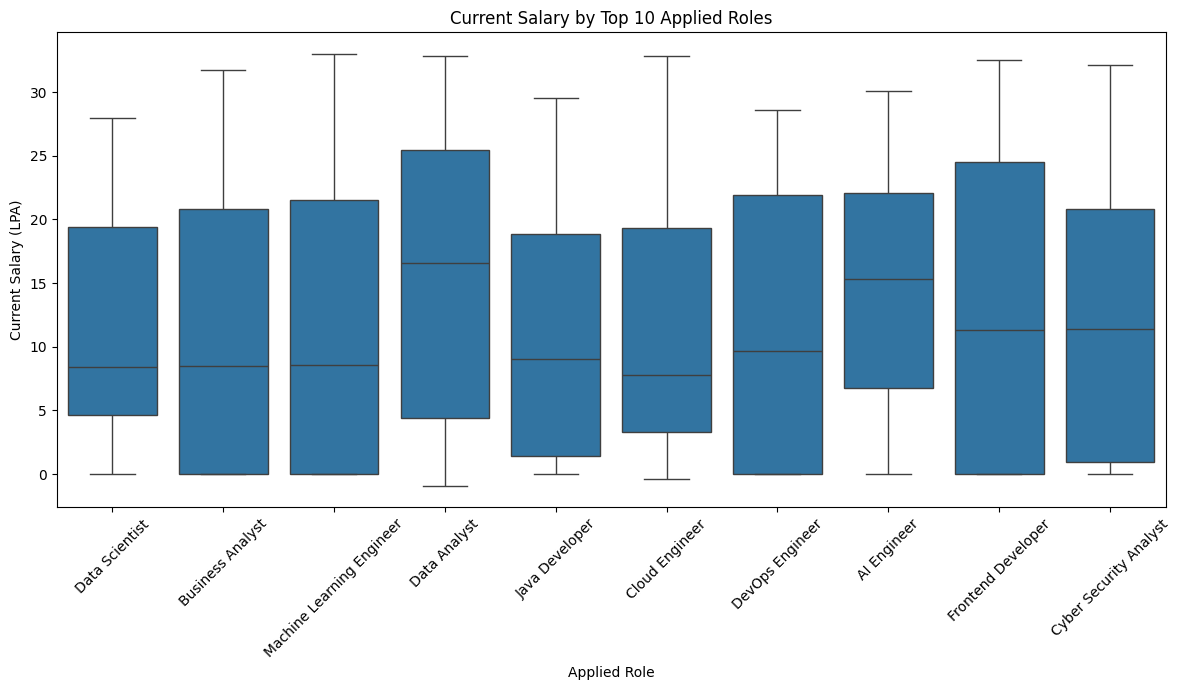

In [145]:
# Top 10 Applied Roles
top_roles = df['Applied_Role'].value_counts().head(10).index

role_data = df[df['Applied_Role'].isin(top_roles)]

# Create single graph
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=role_data,
    y='Current_Salary_LPA',
    x='Applied_Role'
)

plt.title('Current Salary by Top 10 Applied Roles')
plt.ylabel('Current Salary (LPA)')
plt.xlabel('Applied Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

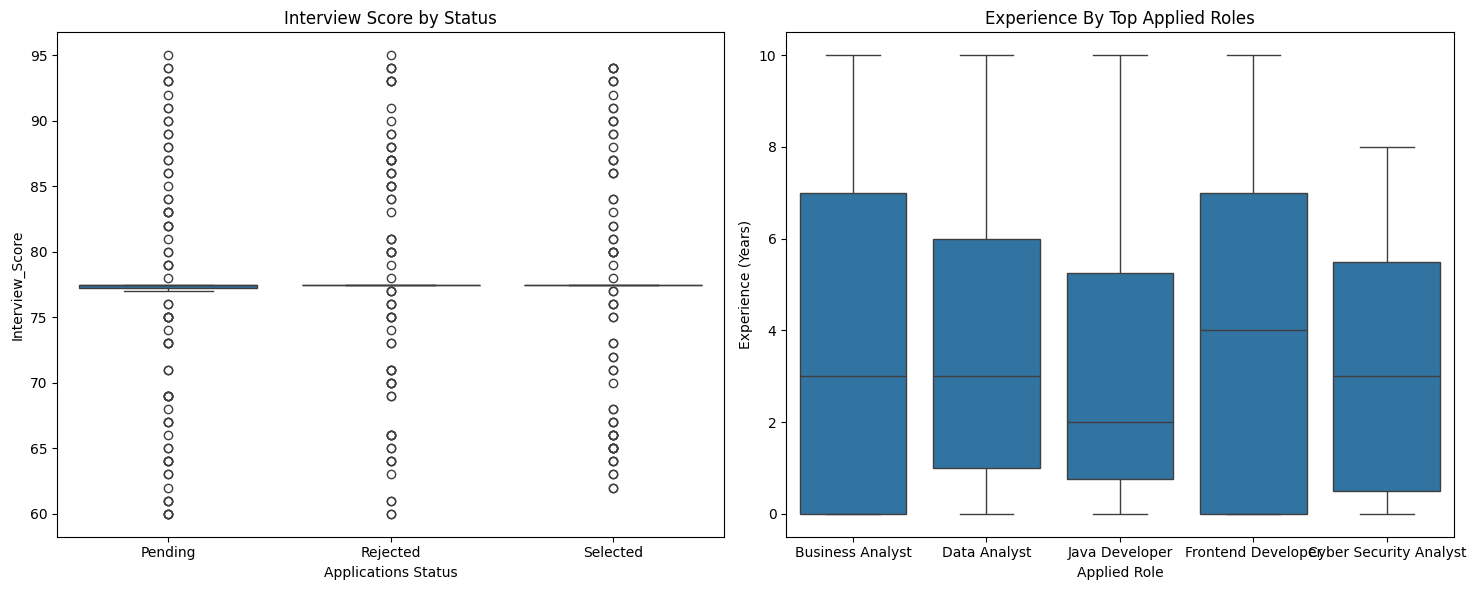

In [154]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

# 2. Interview Score by Status
sns.boxplot(
    data=df,
    x='Status',
    y='Interview_Score',
    ax=axes[0]
)

axes[0].set_title('Interview Score by Status')
axes[0].set_xlabel('Applications Status')
axes[0].set_ylabel('Interview_Score')

# 3. Experience by Applied Role - top 10
top_roles = df['Applied_Role'].value_counts().head(5).index
role_data = df[df['Applied_Role'].isin(top_roles)]

sns.boxplot(
    data=role_data,
    y='Experience_Years',
    x='Applied_Role',
)

axes[1].set_title('Experience By Top Applied Roles')
axes[1].set_ylabel('Experience (Years)')
axes[1].set_xlabel('Applied Role')

plt.tight_layout()
plt.show()

**STEP 6 - TIME SERIES ANALYSIS**

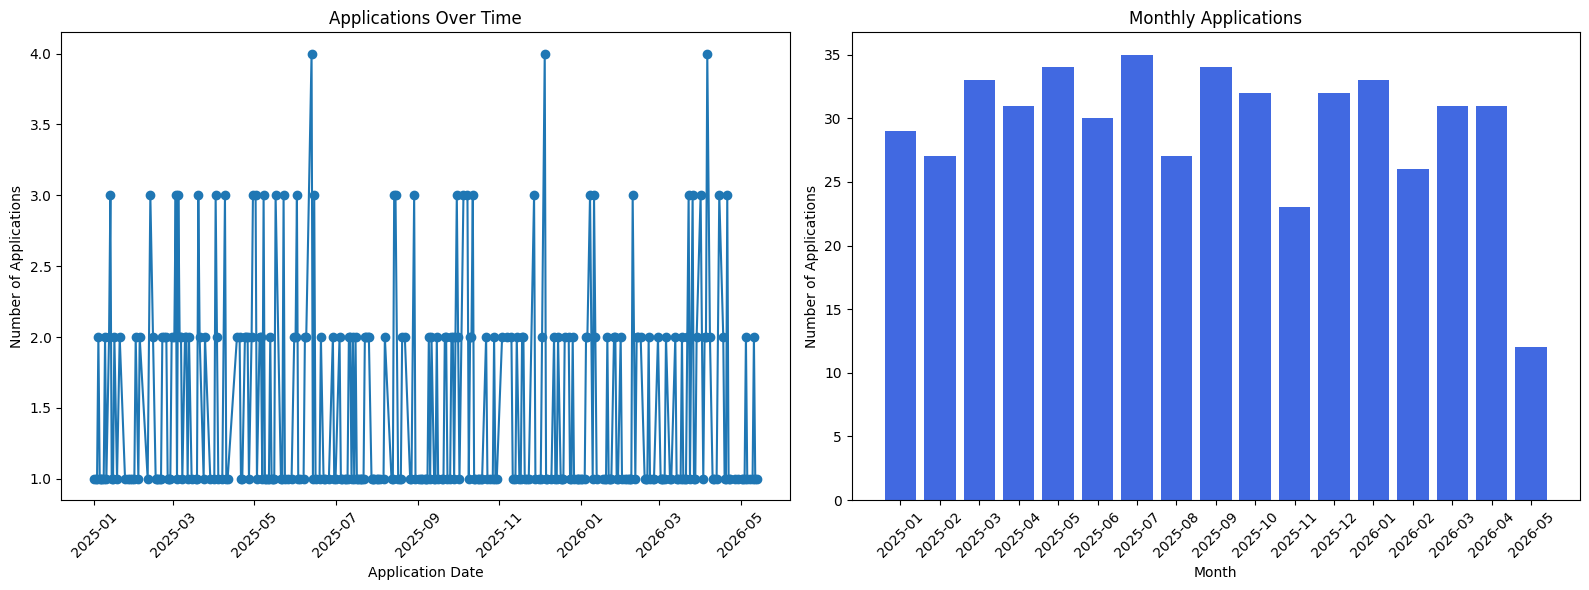

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Applications Over Time

daily_applications = df.groupby('Application_Date').size()
axes[0].plot(
    daily_applications.index,
    daily_applications.values,
    marker='o'
)

axes[0].set_title('Applications Over Time')
axes[0].set_xlabel('Application Date')
axes[0].set_ylabel('Number of Applications')

axes[0].tick_params(axis='x', rotation=45)

# 2. Monthly Applications

monthly_applications = df.groupby(
    df['Application_Date'].dt.to_period('M')
).size()

axes[1].bar(
    monthly_applications.index.astype(str),
    monthly_applications.values,
    color='royalblue'
)

axes[1].set_title('Monthly Applications')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Applications')

axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

**StEP -7 MULTIVARIATE ANALYSIS**

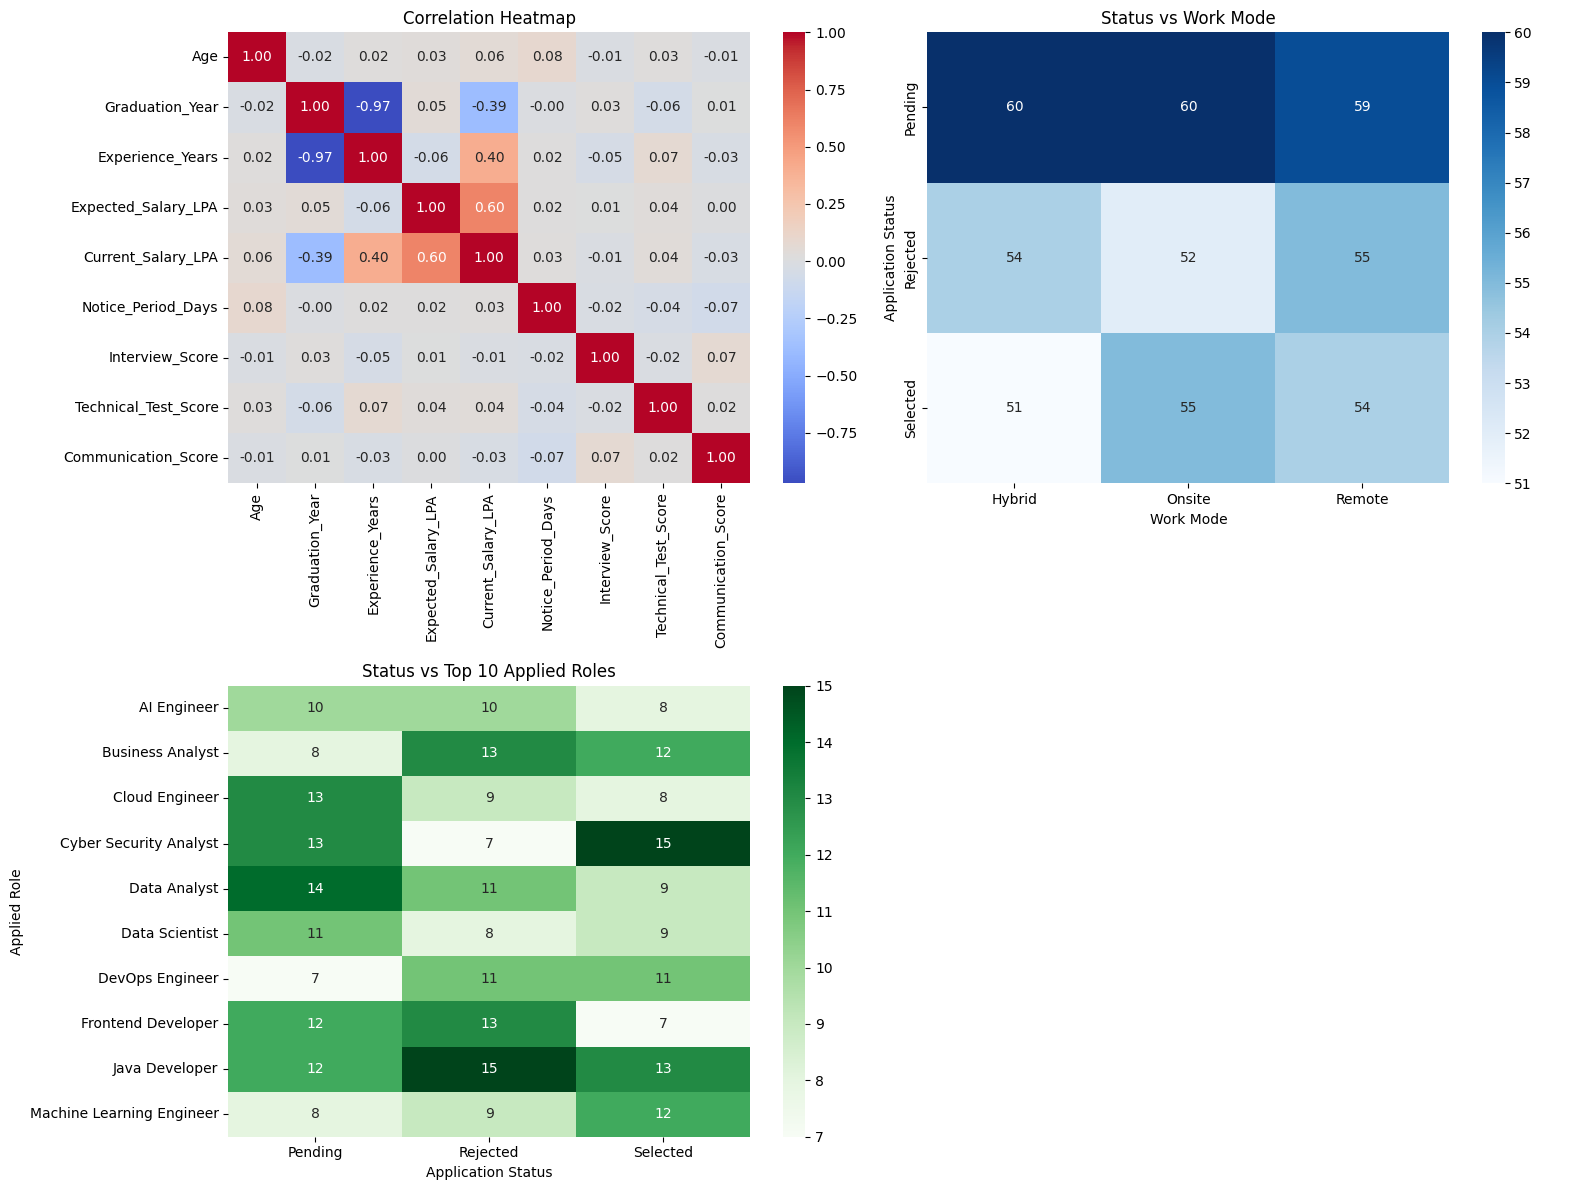

In [168]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# 7.1 CORRELATION HEATMAP
corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[0, 0]
)

axes[0, 0].set_title('Correlation Heatmap')



# 7.2 STATUS + WORK MODE
status_workmode = pandas.crosstab(
    df['Status'],
    df['Work_Mode']
)

sns.heatmap(
    status_workmode,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Status vs Work Mode')
axes[0, 1].set_xlabel('Work Mode')
axes[0, 1].set_ylabel('Application Status')



# 7.3 STATUS + APPLIED ROLE
top_roles = df['Applied_Role'].value_counts().head(10).index

role_data = df[df['Applied_Role'].isin(top_roles)]

status_role = pandas.crosstab(
    role_data['Applied_Role'],
    role_data['Status']
)

sns.heatmap(
    status_role,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Status vs Top 10 Applied Roles')
axes[1, 0].set_xlabel('Application Status')
axes[1, 0].set_ylabel('Applied Role')



# EMPTY 4th PLOT
axes[1, 1].axis('off')


plt.tight_layout()
plt.show()

In [177]:
count = (
    df[df['Applied_Role'] == 'Java Developer']
    .groupby('Status')
    .size()
)
print(count)

Status
Pending     12
Rejected    15
Selected    13
dtype: int64


**STEP 8 - KEY INSIGHTS**

In [181]:
print('         OVERALL DATASET  SUMMARY        \n')
print("Total Candidates:", len(df))
print("Total Columns:", len(df.columns))
print("Total Applied Roles:", df['Applied_Role'].nunique())
print("Total Work Modes:", df['Work_Mode'].nunique())
print("Total Qualifications:", df['Qualification'].nunique())

         OVERALL DATASET  SUMMARY        

Total Candidates: 500
Total Columns: 26
Total Applied Roles: 18
Total Work Modes: 3
Total Qualifications: 7


In [184]:
print("\n APPLICATION STATUS              \n")

status_counts = df['Status'].value_counts()

print(status_counts)


 APPLICATION STATUS              

Status
Pending     179
Rejected    161
Selected    160
Name: count, dtype: int64


In [185]:
work_modes = df['Work_Mode'].value_counts()
print(work_modes)

Work_Mode
Remote    168
Onsite    167
Hybrid    165
Name: count, dtype: int64


In [186]:
top_roles = df['Applied_Role'].value_counts().head(10)

print(top_roles)

Applied_Role
Java Developer               40
Cyber Security Analyst       35
Data Analyst                 34
Business Analyst             33
Frontend Developer           32
Cloud Engineer               30
Machine Learning Engineer    29
DevOps Engineer              29
AI Engineer                  28
Data Scientist               28
Name: count, dtype: int64


**STEP 9 - PROJECT CONCLUSION**

#### **9.1 Overall Findings**
The dataset was analyzed to understand recruitment patterns, including:

- Dataset structure and quality
- Application status
- Work mode
- Applied roles
- Candidate patterns and application trends

#### **9.2 Important Observations**

- Identified application status and candidate distribution.
- Analyzed work mode and applied role patterns.
- Observed application trends over time.
- Examined relationships between key variables.

#### **9.3 HR Insights**

- Identified recruitment pipeline and candidate distribution.
- Analyzed work mode and role-wise application patterns.
- Provided insights into application trends for HR planning.

#### **9.4 Final Conclusion**

This project demonstrates the use of Python, Pandas, Matplotlib, and Seaborn to analyze and visualize recruitment data. The EDA identified patterns in application status, work mode, roles, salary, scores, and application trends.


Overall, the analysis provides a structured understanding of recruitment patterns and can support better analysis of candidate applications and recruitment processes.